In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

# Globální nastavení vzhledu grafů
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

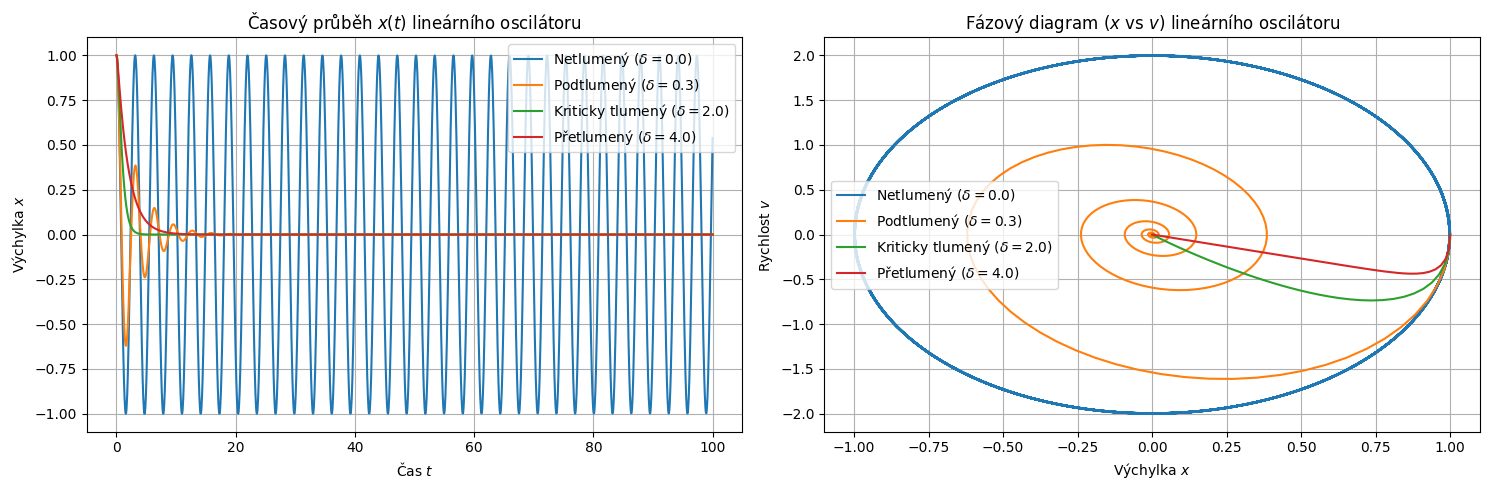


--- Ukázka symbolického řešení netlumeného lineárního oscilátoru ---


In [14]:
def linear_oscillator(t, z, omega0, delta, gamma=0, omega=0):
    """Soustava dvou ODE pro lineární oscilátor."""
    x, v = z
    return [v, -2 * delta * v - (omega0**2) * x + gamma * np.cos(omega * t)]

# --- 1. Numerická simulace (Interval t od 0 do 100 podle zadání) ---
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 2000)
z0 = [1.0, 0.0]  # Počáteční podmínka
omega0 = 2.0

tlumeni_scenare = [
    {"label": r"Netlumený ($\delta=0.0$)", "delta": 0.0},
    {"label": r"Podtlumený ($\delta=0.3$)", "delta": 0.3},
    {"label": r"Kriticky tlumený ($\delta=2.0$)", "delta": 2.0},
    {"label": r"Přetlumený ($\delta=4.0$)", "delta": 4.0}
]

# Vytvoření dvou podgrafů: Časový průběh a Fázový diagram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for scenar in tlumeni_scenare:
    sol = solve_ivp(linear_oscillator, t_span, z0, args=(omega0, scenar["delta"]), t_eval=t_eval)

    # Graf A: Časový průběh x(t)
    ax1.plot(sol.t, sol.y[0], label=scenar["label"])

    # Graf B: Fázový diagram (rychlost v vs výchylka x)
    ax2.plot(sol.y[0], sol.y[1], label=scenar["label"])

# Formátování časového průběhu
ax1.set_title("Časový průběh $x(t)$ lineárního oscilátoru")
ax1.set_xlabel("Čas $t$")
ax1.set_ylabel("Výchylka $x$")
ax1.legend()
ax1.grid(True)

# Formátování fázového diagramu
ax2.set_title("Fázový diagram ($x$ vs $v$) lineárního oscilátoru")
ax2.set_xlabel("Výchylka $x$")
ax2.set_ylabel("Rychlost $v$")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- 2. Analytické řešení pomocí SymPy ---
print("\n--- Ukázka symbolického řešení netlumeného lineárního oscilátoru ---")
t_sym = sp.Symbol('t', real=True, positive=True)
x_sym = sp.Function('x')(t_sym)
w0_sym = sp.Symbol('omega_0', real=True, positive=True)

ode = sp.Eq(x_sym.diff(t_sym, 2) + w0_sym**2 * x_sym, 0)
analyticke_reseni = sp.dsolve(ode, x_sym, ics={x_sym.subs(t_sym, 0): 1, x_sym.diff(t_sym).subs(t_sym, 0): 0})
sp.init_printing(use_unicode=True)
display(analyticke_reseni)

## A) Lineární oscilátor

### Co odlišuje slabé, kritické a silné tlumení?
* **Slabé tlumení:** Systém kmitá (houpe se) sem a tam, ale s každým kmitem se poloha zmenšuje, až se zastaví.
* **Kritické tlumení:** Systém se vrátí do nuly nejrychlejším možným způsobem a vůbec nepřestřelí na druhou stranu.
* **Silné tlumení:** Prostředí klade obrovský odpor (jako by se hýbal v medu). Systém se vrací do nuly strašně pomalu a nudně bez jakéhokoliv kmitu.

### Jak se změní chování systému při změně tlumení o pár procent?
Chování se změní jen nepatrně. Grafy se posunou jen o kousek (např. kmitání zanikne o něco dříve nebo později).

### Je přechod mezi režimy plynulý nebo kvalitativně ostrý?
* **Matematicky je ostrý:** Přesně v bodě kritického tlumení se mění rovnice a kmitání se úplně vypne.
* **Vizuálně v grafu je plynulý:** Pokud jsme těsně pod hranicí, kmitání je už tak slabé, že lidské oko rozdíl od čistého vrácení do nuly skoro nepozná.

### Jaký mechanismus vede k rezonanci?
Rezonance nastane, když se trefíme frekvencí buzení (jak rychle do toho strkáme) do vlastní frekvence oscilátoru (jak rychle se chce kývat sám). Síla pak působí vždy ve správný moment a amplituda začne prudce růst.

### Dá se problém řešit pomocí symbolické matematiky? Jak?
**Ano, dá.** Protože je to lineární rovnice, existuje na ni přesný vzorec. V Pythonu stačí použít knihovnu `sympy` a funkci `dsolve()`, která nám vyplivne hotový matematický zápis (viz ukázka výše).

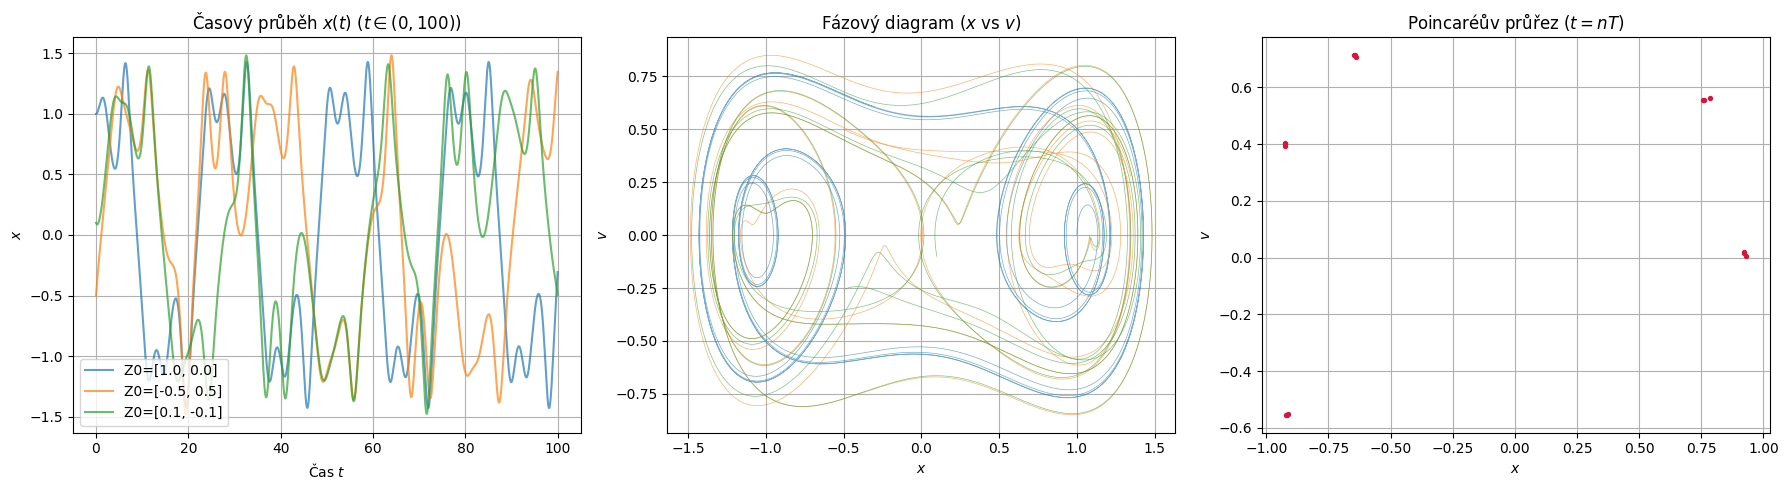

In [15]:
def duffing_oscillator(t, z, alpha, beta, delta, gamma, omega):
    """Soustava dvou ODE pro Duffingův oscilátor."""
    x, v = z
    return [v, -delta*v - alpha*x - beta*(x**3) + gamma*np.cos(omega*t)]

# Parametry striktně podle zadání
alpha, beta, delta, gamma, omega = -1.0, 1.0, 0.2, 0.3, 1.2
T = 2 * np.pi / omega  # Perioda vnějšího buzení

# Přesný interval simulace t z intervalu (0, 100) podle zadání
t_span = (0, 100)
t_eval = np.linspace(0, 100, 10000)

# Více počátečních podmínek
pocatecni_podminky = [[1.0, 0.0], [-0.5, 0.5], [0.1, -0.1]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Simulace pro různé počáteční podmínky
for i, z0 in enumerate(pocatecni_podminky):
    sol_duff = solve_ivp(duffing_oscillator, t_span, z0, args=(alpha, beta, delta, gamma, omega), t_eval=t_eval)

    # 1. Časový průběh x(t) v intervalu (0, 100)
    ax1.plot(sol_duff.t, sol_duff.y[0], alpha=0.7, label=f"Z0={z0}")

    # 2. Celkový fázový diagram (x vs v) v intervalu (0, 100)
    ax2.plot(sol_duff.y[0], sol_duff.y[1], lw=0.5, alpha=0.6)

# --- 3. Výpočet Poincaréova průřezu (Pouze body v časech t = n * T uvnitř intervalu 100) ---
t_poincare = np.arange(0, 100, T)
sol_poincare = solve_ivp(duffing_oscillator, t_span, pocatecni_podminky[0], args=(alpha, beta, delta, gamma, omega), t_eval=t_poincare)

# Zahodíme prvních několik bodů (přechodový děj), aby zbyl čistší atraktor
cut = 5
ax3.scatter(sol_poincare.y[0][cut:], sol_poincare.y[1][cut:], s=8, color='crimson', zorder=3)

# Popisky grafů
ax1.set_title(r"Časový průběh $x(t)$ ($t \in (0, 100)$)")
ax1.set_xlabel("Čas $t$"); ax1.set_ylabel("$x$"); ax1.legend()

ax2.set_title("Fázový diagram ($x$ vs $v$)")
ax2.set_xlabel("$x$"); ax2.set_ylabel("$v$")

ax3.set_title("Poincaréův průřez ($t = nT$)")
ax3.set_xlabel("$x$"); ax3.set_ylabel("$v$")

plt.tight_layout()
plt.show()

## B) Duffingův oscilátor

### Dochází pro dané parametry k chaotickému chování?
**Ano, dochází.** Časový graf skáče úplně náhodně a fázový diagram se nikdy neuzavře do stejné smyčky. Hlavním důkazem je Poincaréův průřez, kde body tvoří "mrak" (podivný atraktor) a nekončí v jednom bodě.

### Jaký je rozdíl mezi malou a velkou počáteční podmínkou?
* **Malá podmínka:** Systém se houpá jen na dně jedné ze dvou potenciálových studní (kolem jednoho stabilního bodu).
* **Velká podmínka:** Systém získá dost energie na to, aby dokázal přeskakovat kopec mezi oběma studnami, což spustí chaos.

### Co se stane, když zvýšíte buzení gamma?
Dodáme do systému víc energie. Může se stát, že chaos ještě zesílí, nebo naopak při určité síle systém "vyskočí" z chaosu a začne kmitat úplně pravidelně.

### Mění se počet atraktorů?
**Ano, mění.** Podle toho, jak silně systém budíme, se mohou staré chaotické atraktory rozpadat a mohou vznikat nové, stabilní pravidelné dráhy.

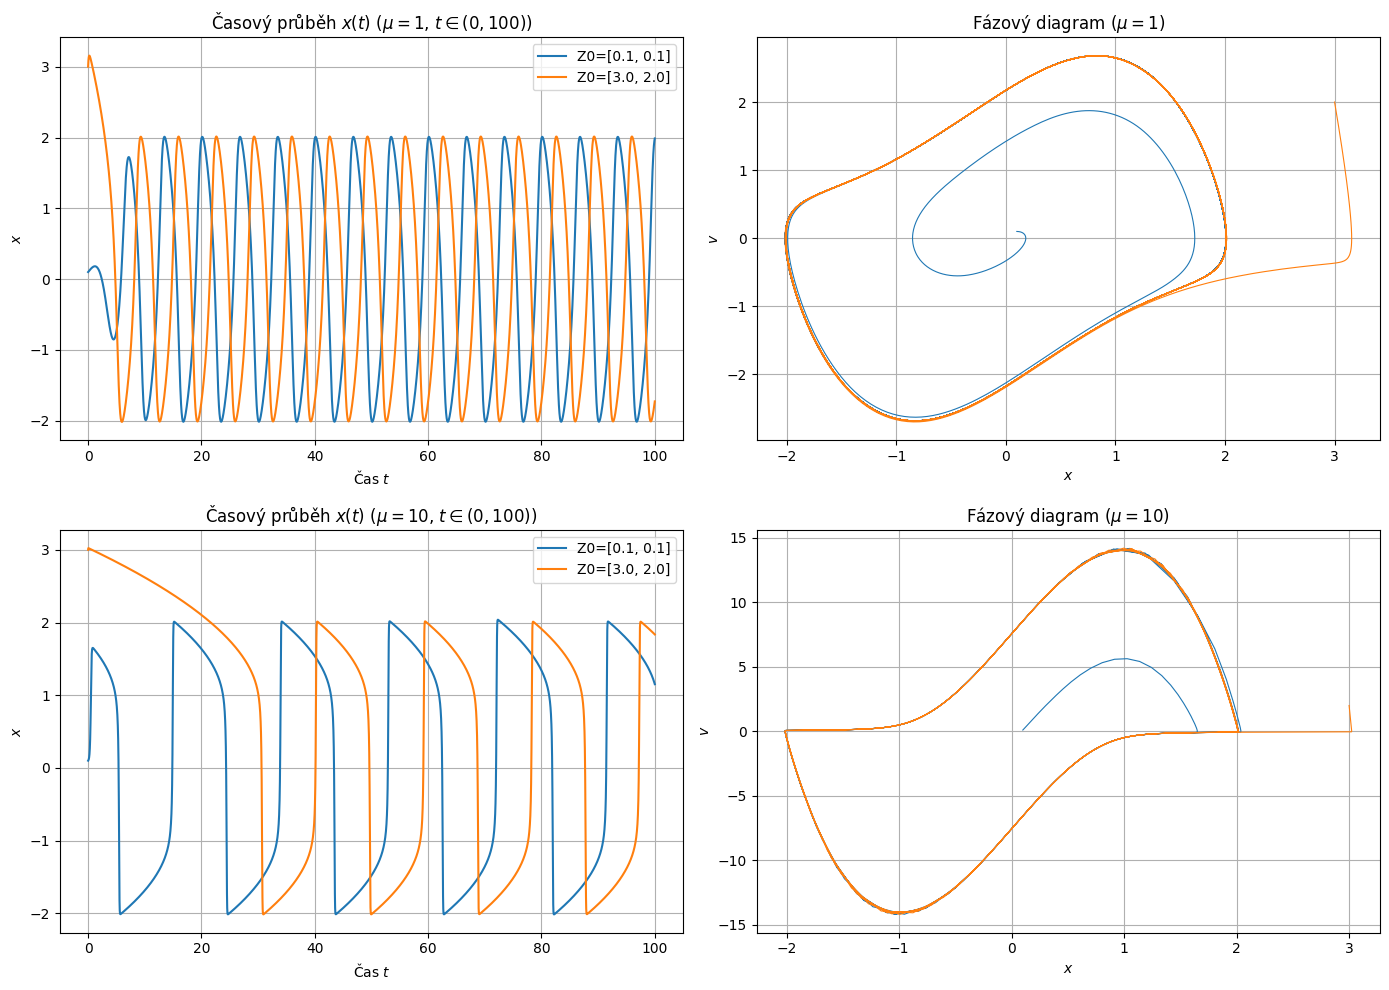

In [16]:
def vanderpol_oscillator(t, z, mu):
    """Soustava dvou ODE pro Van der Polův oscilátor."""
    x, v = z
    return [v, mu * (1 - x**2) * v - x]

# Přesný interval simulace t z intervalu (0, 100) podle zadání
t_span_vdp = (0, 100)
t_eval_vdp = np.linspace(0, 100, 5000)
ic_vdp = [[0.1, 0.1], [3.0, 2.0]]  # Počáteční podmínky (uvnitř a vně cyklu)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Simulace pro mu = 1.0 v intervalu (0, 100) ---
for z0 in ic_vdp:
    sol_vdp1 = solve_ivp(vanderpol_oscillator, t_span_vdp, z0, args=(1.0,), t_eval=t_eval_vdp)
    axes[0, 0].plot(sol_vdp1.t, sol_vdp1.y[0], label=f"Z0={z0}")
    axes[0, 1].plot(sol_vdp1.y[0], sol_vdp1.y[1], lw=0.8)
axes[0, 0].set_title(r"Časový průběh $x(t)$ ($\mu = 1$, $t \in (0, 100)$)")
axes[0, 1].set_title(r"Fázový diagram ($\mu = 1$)")

# --- Simulace pro mu = 10.0 v intervalu (0, 100) ---
for z0 in ic_vdp:
    sol_vdp10 = solve_ivp(vanderpol_oscillator, t_span_vdp, z0, args=(10.0,), t_eval=t_eval_vdp)
    axes[1, 0].plot(sol_vdp10.t, sol_vdp10.y[0], label=f"Z0={z0}")
    axes[1, 1].plot(sol_vdp10.y[0], sol_vdp10.y[1], lw=0.8)
axes[1, 0].set_title(r"Časový průběh $x(t)$ ($\mu = 10$, $t \in (0, 100)$)")
axes[1, 1].set_title(r"Fázový diagram ($\mu = 10$)")

# Formátování
for row in axes:
    row[0].set_ylabel("$x$"); row[0].set_xlabel("Čas $t$"); row[0].legend()
    row[1].set_ylabel("$v$"); row[1].set_xlabel("$x$")
plt.tight_layout()
plt.show()

## C) Van der Polův oscilátor

### Jak se mění tvar limitního cyklu při přechodu z mu = 1 na mu = 10?
* Pro **$\mu = 1$** je limitní cyklus kulatý a hladký (skoro jako elipsa) a vlna vypadá jako běžná sinusovka.
* Pro **$\mu = 10$** se cyklus úplně zdeformuje, získá ostré rohy a graf připomíná spíše hranaté zuby.

### Proč při velkém mu vznikají rychlé skoky a pomalé fáze?
Je to kvůli nelineárnímu tlumení. Když je výchylka velká, systém strašně moc brzdí a pohybuje se šnečí rychlostí (**pomalá fáze**). Jakmile ale propadne do středu, tlumení se otočí, začne ho obrovskou silou zrychlovat a systém bleskově přeletí na druhou stranu (**rychlý skok**).

### Jaký je vliv počátečních podmínek na konečné chování?
Vliv je **nulový**. Je úplně jedno, jestli začneme blízko nuly, nebo s obrovskou výchylkou. Po chvíli se trajektorie pokaždé namotá na ten samý limitní cyklus.

### Existuje v modelu více atraktorů?
**Ne, neexistuje.** V tomto základním nastavení má model pouze jeden jediný atraktor – ten jeden konečný limitní cyklus.